## Data Collection


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##  Loading Data 

In [8]:
# Load the Excel file
file_path = r"C:\Users\linga\OneDrive\Desktop\Dataset\Healthcare Operations Analytics Dataset\healthcare_dataset.xlsx"
xls = pd.ExcelFile(file_path)

# Load each sheet into a separate DataFrame
patients_details_df = pd.read_excel(xls, sheet_name='Patients_details')
hospital_details_df = pd.read_excel(xls, sheet_name='Hospital_Details')
doctor_details_df = pd.read_excel(xls, sheet_name='Doctor_Details')
patients_data_df = pd.read_excel(xls, sheet_name='Patients_Data')

## Merging Tables

In [26]:
# Merge patients_data with patients_details on P_ID
merged_df = pd.merge(patients_data_df, patients_details_df, on='P_ID', how='left')

# Merge with doctor_details on D_ID
merged_df = pd.merge(merged_df, doctor_details_df, on='D_ID', how='left')

# Merge with hospital_details on H_ID (note H_id in one table, H_ID in the other)
hospital_details_df.rename(columns={'H_id': 'H_ID'}, inplace=True)
merged_df = pd.merge(merged_df, hospital_details_df, on='H_ID', how='left')

In [27]:
merged_df.head() #First 5 Elements

,P_ID,D_ID,H_ID,Medical Condition,Date of Admission,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Name,Age,Gender,Blood Type,Doctor,Hospital
0,1.0,30256,16666,Cancer,2021-03-10,UnitedHealthcare,26052.106404,363,Elective,2021-03-29,Lipitor,Inconclusive,aAroN ADaMS,38.0,Female,O-,Norma Li,Hart LLC
1,2.0,21581,26920,Diabetes,2023-02-26,UnitedHealthcare,27087.560553,300,Emergency,2023-03-13,Aspirin,NaN,aAROn aguIRRe,36.0,Male,A-,Katrina Luna,Murray-Shelton
2,3.0,22170,35639,Asthma,2020-12-18,Cigna,39804.658624,196,Urgent,2021-01-15,Aspirin,Inconclusive,AArOn AnderSoN,50.0,Female,A+,Kenneth Jennings,Tanner-Cox
3,4.0,36870,31042,Hypertension,2021-03-28,UnitedHealthcare,16846.415799,249,Elective,2021-04-09,Paracetamol,Abnormal,aaRON AndeRSoN md,20.0,Female,A-,Tammy Perez,Ritter LLC
4,5.0,9015,25936,Cancer,2021-01-10,Medicare,10602.077185,108,Urgent,2021-01-17,Paracetamol,Inconclusive,AAron ArCHER,NaN,Female,B-,Cynthia Villanueva,"Montes Case and Mendez,"


In [28]:
merged_df. tail() #Last 5 Elements

,P_ID,D_ID,H_ID,Medical Condition,Date of Admission,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Name,Age,Gender,Blood Type,Doctor,Hospital
55495,54941.0,2127,20144,Asthma,2021-07-25,Aetna,16668.258866,476,Urgent,2021-07-30,Aspirin,Inconclusive,Zoe Jackson,38.0,Male,A-,Andrew Hall,Jones PLC
55496,54942.0,9999,20132,Cancer,2024-03-22,Medicare,9024.092301,178,Elective,2024-04-08,Penicillin,Inconclusive,ZoE ROdRiGuEz,53.0,Female,O+,David Keller,Jones Ltd
55497,54942.0,9999,20132,Cancer,2024-03-22,Medicare,9024.092301,178,Elective,2024-04-08,Penicillin,Inconclusive,ZoE ROdRiGuEz,53.0,Female,O+,David Keller,Jones Ltd
55498,54943.0,26092,18852,Obesity,2022-02-24,Aetna,33252.225130,272,Emergency,2022-03-15,Penicillin,Inconclusive,Zoe SmITh,36.0,Male,AB-,Mary Bates,Inc Morales
55499,54944.0,14894,23054,Diabetes,2020-05-29,Medicare,28747.964184,267,Emergency,2020-05-30,Ibuprofen,Normal,ZoE WhIte,25.0,Female,AB+,Heidi Kennedy,Ltd Estes


In [29]:
# Information of table
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   P_ID                55497 non-null  float64       
 1   D_ID                55500 non-null  int64         
 2   H_ID                55500 non-null  int64         
 3   Medical Condition   55500 non-null  str           
 4   Date of Admission   55500 non-null  datetime64[us]
 5   Insurance Provider  55500 non-null  str           
 6   Billing Amount      55500 non-null  float64       
 7   Room Number         55500 non-null  int64         
 8   Admission Type      55500 non-null  str           
 9   Discharge Date      55500 non-null  datetime64[us]
 10  Medication          55500 non-null  str           
 11  Test Results        55492 non-null  str           
 12  Name                55497 non-null  str           
 13  Age                 55493 non-null  float64       
 14  G

In [30]:
# Describe the Table
merged_df.describe()

,P_ID,D_ID,H_ID,Date of Admission,Billing Amount,Room Number,Discharge Date,Age
count,55497.000000,55500.000000,55500.000000,55500,55500.000000,55500.000000,55500,55493.000000
mean,27478.106979,20195.877604,20362.033892,2021-11-01 01:02:22.443243,25539.316097,301.134829,2021-11-16 13:15:20.821621,51.539041
min,1.000000,1.000000,1.000000,2019-05-08 00:00:00,-2008.492140,101.000000,2019-05-09 00:00:00,13.000000
25%,13731.000000,10152.750000,11108.750000,2020-07-28 00:00:00,13241.224652,202.000000,2020-08-12 00:00:00,35.000000
50%,27487.000000,20051.500000,20513.500000,2021-11-01 00:00:00,25538.069376,302.000000,2021-11-17 00:00:00,52.000000
75%,41207.000000,30112.250000,29667.000000,2023-02-03 00:00:00,37820.508436,401.000000,2023-02-18 00:00:00,68.000000
max,54944.000000,40341.000000,39876.000000,2024-05-07 00:00:00,52764.276736,500.000000,2024-06-06 00:00:00,89.000000
std,15860.379707,11531.448639,11142.462206,NaN,14211.454431,115.243069,NaN,19.602661


In [31]:
# Get descriptive statistics for all columns, not just the numeric ones.
merged_df.describe(include="all")

,P_ID,D_ID,H_ID,Medical Condition,Date of Admission,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Name,Age,Gender,Blood Type,Doctor,Hospital
count,55497.000000,55500.000000,55500.000000,55500,55500,55500,55500.000000,55500.000000,55500,55500,55500,55492,55497,55493.000000,55497,55497,55500,55500
unique,NaN,NaN,NaN,6,NaN,5,NaN,NaN,3,NaN,5,3,49974,NaN,2,8,40341,39876
top,NaN,NaN,NaN,Arthritis,NaN,Cigna,NaN,NaN,Elective,NaN,Lipitor,Abnormal,DAvId muNoZ,NaN,Male,A-,Michael Smith,LLC Smith
freq,NaN,NaN,NaN,9308,NaN,11249,NaN,NaN,18655,NaN,11140,18624,3,NaN,27773,6969,27,44
mean,27478.106979,20195.877604,20362.033892,NaN,2021-11-01 01:02:22.443243,NaN,25539.316097,301.134829,NaN,2021-11-16 13:15:20.821621,NaN,NaN,NaN,51.539041,NaN,NaN,NaN,NaN
min,1.000000,1.000000,1.000000,NaN,2019-05-08 00:00:00,NaN,-2008.492140,101.000000,NaN,2019-05-09 00:00:00,NaN,NaN,NaN,13.000000,NaN,NaN,NaN,NaN
25%,13731.000000,10152.750000,11108.750000,NaN,2020-07-28 00:00:00,NaN,13241.224652,202.000000,NaN,2020-08-12 00:00:00,NaN,NaN,NaN,35.000000,NaN,NaN,NaN,NaN
50%,27487.000000,20051.500000,20513.500000,NaN,2021-11-01 00:00:00,NaN,25538.069376,302.000000,NaN,2021-11-17 00:00:00,NaN,NaN,NaN,52.000000,NaN,NaN,NaN,NaN
75%,41207.000000,30112.250000,29667.000000,NaN,2023-02-03 00:00:00,NaN,37820.508436,401.000000,NaN,2023-02-18 00:00:00,NaN,NaN,NaN,68.000000,NaN,NaN,NaN,NaN
max,54944.000000,40341.000000,39876.000000,NaN,2024-05-07 00:00:00,NaN,52764.276736,500.000000,NaN,2024-06-06 00:00:00,NaN,NaN,NaN,89.000000,NaN,NaN,NaN,NaN


In [32]:
# Check for NaNs etc
merged_df.count()

P_ID                  55497
D_ID                  55500
H_ID                  55500
Medical Condition     55500
Date of Admission     55500
Insurance Provider    55500
Billing Amount        55500
Room Number           55500
Admission Type        55500
Discharge Date        55500
Medication            55500
Test Results          55492
Name                  55497
Age                   55493
Gender                55497
Blood Type            55497
Doctor                55500
Hospital              55500
dtype: int64

In [34]:
merged_df.shape

(55500, 18)

In [35]:
# Datatypes
merged_df.dtypes

P_ID                         float64
D_ID                           int64
H_ID                           int64
Medical Condition                str
Date of Admission     datetime64[us]
Insurance Provider               str
Billing Amount               float64
Room Number                    int64
Admission Type                   str
Discharge Date        datetime64[us]
Medication                       str
Test Results                     str
Name                             str
Age                          float64
Gender                           str
Blood Type                       str
Doctor                           str
Hospital                         str
dtype: object

## Data Cleaning

### Removing Empty Space

In [51]:
# Clean extra spaces and standardize text formatting
merged_df['Name'] = merged_df['Name'].str.strip().str.title()
merged_df['Doctor'] = merged_df['Doctor'].str.strip().str.title()
merged_df['Hospital'] = merged_df['Hospital'].str.strip().str.title()

In [52]:
merged_df.head()

,P_ID,D_ID,H_ID,Medical Condition,Date of Admission,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Name,Age,Gender,Blood Type,Doctor,Hospital
0,1.0,30256,16666,Cancer,2021-03-10,UnitedHealthcare,26052.106404,363,Elective,2021-03-29,Lipitor,Inconclusive,Aaron Adams,38.0,Female,O-,Norma Li,Hart Llc
1,2.0,21581,26920,Diabetes,2023-02-26,UnitedHealthcare,27087.560553,300,Emergency,2023-03-13,Aspirin,NaN,Aaron Aguirre,36.0,Male,A-,Katrina Luna,Murray-Shelton
2,3.0,22170,35639,Asthma,2020-12-18,Cigna,39804.658624,196,Urgent,2021-01-15,Aspirin,Inconclusive,Aaron Anderson,50.0,Female,A+,Kenneth Jennings,Tanner-Cox
3,4.0,36870,31042,Hypertension,2021-03-28,UnitedHealthcare,16846.415799,249,Elective,2021-04-09,Paracetamol,Abnormal,Aaron Anderson Md,20.0,Female,A-,Tammy Perez,Ritter Llc
4,5.0,9015,25936,Cancer,2021-01-10,Medicare,10602.077185,108,Urgent,2021-01-17,Paracetamol,Inconclusive,Aaron Archer,NaN,Female,B-,Cynthia Villanueva,"Montes Case And Mendez,"


In [53]:
#It checks whether your merged data contains invalid or unmatched Patient, Hospital, or Doctor IDs.

# Check for Unmatched Patient IDS (P_ID)
invalidid_pids = merged_df[merged_df['P_ID'].isin(~patients_details_df['P_ID'])]

# Check for Unmatched Patient IDS (D_ID)
invalidid_hids = merged_df[merged_df['H_ID'].isin(~hospital_details_df['H_ID'])]

# Check for Unmatched Patient IDS (D_ID)
invalidid_dids = merged_df[merged_df['D_ID'].isin(~doctor_details_df['D_ID'])]

print("invalidid_pids:", invalidid_pids)
print("invalidid_hids:", invalidid_hids)
print("invalidid_dids:", invalidid_dids)

invalidid_pids: Empty DataFrame
Columns: [P_ID, D_ID, H_ID, Medical Condition, Date of Admission, Insurance Provider, Billing Amount, Room Number, Admission Type, Discharge Date, Medication, Test Results, Name, Age, Gender, Blood Type, Doctor, Hospital]
Index: []
invalidid_hids: Empty DataFrame
Columns: [P_ID, D_ID, H_ID, Medical Condition, Date of Admission, Insurance Provider, Billing Amount, Room Number, Admission Type, Discharge Date, Medication, Test Results, Name, Age, Gender, Blood Type, Doctor, Hospital]
Index: []
invalidid_dids: Empty DataFrame
Columns: [P_ID, D_ID, H_ID, Medical Condition, Date of Admission, Insurance Provider, Billing Amount, Room Number, Admission Type, Discharge Date, Medication, Test Results, Name, Age, Gender, Blood Type, Doctor, Hospital]
Index: []


### Removing Missing Values

In [68]:
# Checking the missing values
merged_df.isnull().sum()

P_ID                  3
D_ID                  0
H_ID                  0
Medical Condition     0
Date of Admission     0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          8
Name                  3
Age                   7
Gender                3
Blood Type            3
Doctor                0
Hospital              0
dtype: int64

In [69]:
# Drop rows where essntial patient info is missing (eg. Patient ID)
df = merged_df.dropna(subset=['P_ID'])

In [70]:
df.count()

P_ID                  55497
D_ID                  55497
H_ID                  55497
Medical Condition     55497
Date of Admission     55497
Insurance Provider    55497
Billing Amount        55497
Room Number           55497
Admission Type        55497
Discharge Date        55497
Medication            55497
Test Results          55489
Name                  55497
Age                   55493
Gender                55497
Blood Type            55497
Doctor                55497
Hospital              55497
dtype: int64

In [71]:
# Fill Missing numerical values (eg., Age) with Median
df['Age'] = df['Age'].fillna(df['Age'].median())
df.count()

P_ID                  55497
D_ID                  55497
H_ID                  55497
Medical Condition     55497
Date of Admission     55497
Insurance Provider    55497
Billing Amount        55497
Room Number           55497
Admission Type        55497
Discharge Date        55497
Medication            55497
Test Results          55489
Name                  55497
Age                   55497
Gender                55497
Blood Type            55497
Doctor                55497
Hospital              55497
dtype: int64

In [72]:
df.isnull().sum()

P_ID                  0
D_ID                  0
H_ID                  0
Medical Condition     0
Date of Admission     0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          8
Name                  0
Age                   0
Gender                0
Blood Type            0
Doctor                0
Hospital              0
dtype: int64

In [73]:
# Fill missing Categorical Values (e.g., Test Results) with mode
df['Test Results'] = df['Test Results'].fillna(df['Test Results'].mode()[0])
df.count()

P_ID                  55497
D_ID                  55497
H_ID                  55497
Medical Condition     55497
Date of Admission     55497
Insurance Provider    55497
Billing Amount        55497
Room Number           55497
Admission Type        55497
Discharge Date        55497
Medication            55497
Test Results          55497
Name                  55497
Age                   55497
Gender                55497
Blood Type            55497
Doctor                55497
Hospital              55497
dtype: int64

In [74]:
# Verify whether any missing values remain
df.isnull().sum()

P_ID                  0
D_ID                  0
H_ID                  0
Medical Condition     0
Date of Admission     0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
Name                  0
Age                   0
Gender                0
Blood Type            0
Doctor                0
Hospital              0
dtype: int64

### Removing Duplicate Data  

In [75]:
# Check for duplicates (entire row match)
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

Total duplicate rows: 534


In [78]:
# Viewing duplicate rows 
duplicates = df[df.duplicated()]
print(duplicates.head())

        P_ID   D_ID   H_ID Medical Condition Date of Admission  \
226    226.0  12193  26200      Hypertension        2022-12-15   
376    375.0   4152  32496      Hypertension        2022-01-02   
609    607.0  13634  33309          Diabetes        2022-03-27   
874    871.0  11324   5130         Arthritis        2024-01-17   
1023  1019.0  24223  11717          Diabetes        2023-12-24   

     Insurance Provider  Billing Amount  Room Number Admission Type  \
226    UnitedHealthcare     1983.568297          192       Elective   
376               Cigna    16294.907725          180         Urgent   
609               Aetna    39525.674902          246      Emergency   
874    UnitedHealthcare     4177.715918          450         Urgent   
1023              Aetna     1903.879223          385       Elective   

     Discharge Date   Medication  Test Results                Name   Age  \
226      2023-01-13    Ibuprofen        Normal       Abigail Young  41.0   
376      2022-01-30    I

In [79]:
# Drop duplicate rows 
df = df.drop_duplicates()

In [82]:
len(df)

54963

In [83]:
# drop based on a specific subset (e.g., Patient_ID + Date)
df1 = df.drop_duplicates(subset=['P_ID', 'Date of Admission'])
len(df1)

54963

In [29]:
print(f"\nData shape after removing duplicates: {df.shape}")


Data shape after removing duplicates: (54963, 18)


In [84]:
# Verifing duplicates are removed 
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

Total duplicate rows: 0


###  Converting Data Types 

In [85]:
# Convert 'Date of Admission' & 'Date of Discharge' to datetime format
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'], errors='coerce', dayfirst=True) # we are telling Date start with Day  
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'], errors='coerce', format='%d-%m-%y') #Customize the date format

df.dtypes

P_ID                         float64
D_ID                           int64
H_ID                           int64
Medical Condition                str
Date of Admission     datetime64[us]
Insurance Provider               str
Billing Amount               float64
Room Number                    int64
Admission Type                   str
Discharge Date        datetime64[us]
Medication                       str
Test Results                     str
Name                             str
Age                          float64
Gender                           str
Blood Type                       str
Doctor                           str
Hospital                         str
dtype: object

In [91]:
print(df)

          P_ID   D_ID   H_ID Medical Condition Date of Admission  \
0          1.0  30256  16666            Cancer        2021-03-10   
1          2.0  21581  26920          Diabetes        2023-02-26   
2          3.0  22170  35639            Asthma        2020-12-18   
3          4.0  36870  31042      Hypertension        2021-03-28   
4          5.0   9015  25936            Cancer        2021-01-10   
...        ...    ...    ...               ...               ...   
55494  54940.0  32747  21399          Diabetes        2022-09-24   
55495  54941.0   2127  20144            Asthma        2021-07-25   
55496  54942.0   9999  20132            Cancer        2024-03-22   
55498  54943.0  26092  18852           Obesity        2022-02-24   
55499  54944.0  14894  23054          Diabetes        2020-05-29   

      Insurance Provider  Billing Amount  Room Number Admission Type  \
0       UnitedHealthcare    26052.106404          363       Elective   
1       UnitedHealthcare    27087.56055

In [92]:
#Converting format of date
custom_date = df['Date of Admission'].dt.strftime('%d-%m-%Y')

In [93]:
custom_date

0        10-03-2021
1        26-02-2023
2        18-12-2020
3        28-03-2021
4        10-01-2021
            ...    
55494    24-09-2022
55495    25-07-2021
55496    22-03-2024
55498    24-02-2022
55499    29-05-2020
Name: Date of Admission, Length: 54963, dtype: str

In [97]:
custom_date.dtypes

<StringDtype(storage='python', na_value=nan)>

In [98]:
# Convert Billing Amount to numric(float)
df['Billing Amount'] = pd.to_numeric(df['Billing Amount'], errors = 'coerce')
df.dtypes

P_ID                         float64
D_ID                           int64
H_ID                           int64
Medical Condition                str
Date of Admission     datetime64[us]
Insurance Provider               str
Billing Amount               float64
Room Number                    int64
Admission Type                   str
Discharge Date        datetime64[us]
Medication                       str
Test Results                     str
Name                             str
Age                          float64
Gender                           str
Blood Type                       str
Doctor                           str
Hospital                         str
dtype: object

In [99]:
# Convert P_ID to Str
df['P_ID'] = df['P_ID'].astype(str)
df.dtypes

P_ID                             str
D_ID                           int64
H_ID                           int64
Medical Condition                str
Date of Admission     datetime64[us]
Insurance Provider               str
Billing Amount               float64
Room Number                    int64
Admission Type                   str
Discharge Date        datetime64[us]
Medication                       str
Test Results                     str
Name                             str
Age                          float64
Gender                           str
Blood Type                       str
Doctor                           str
Hospital                         str
dtype: object

In [100]:
# Again Coverting P_ID to numeric
df['P_ID'] = pd.to_numeric(df['P_ID'])
df.dtypes

P_ID                         float64
D_ID                           int64
H_ID                           int64
Medical Condition                str
Date of Admission     datetime64[us]
Insurance Provider               str
Billing Amount               float64
Room Number                    int64
Admission Type                   str
Discharge Date        datetime64[us]
Medication                       str
Test Results                     str
Name                             str
Age                          float64
Gender                           str
Blood Type                       str
Doctor                           str
Hospital                         str
dtype: object

In [101]:
# Convert 'Age' to integer
df['Age'] = pd.to_numeric(df['Age'], errors='coerce').astype('Int64')

In [102]:
print(df.dtypes)

P_ID                         float64
D_ID                           int64
H_ID                           int64
Medical Condition                str
Date of Admission     datetime64[us]
Insurance Provider               str
Billing Amount               float64
Room Number                    int64
Admission Type                   str
Discharge Date        datetime64[us]
Medication                       str
Test Results                     str
Name                             str
Age                            Int64
Gender                           str
Blood Type                       str
Doctor                           str
Hospital                         str
dtype: object


### Creating New Derived Columns 

In [103]:
# Calculate length of stay
df['Length of Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

# Flag high billing amounts
df['High Bill Flag'] = df['Billing Amount'].apply(lambda x: 'High' if x > 30000 else 'Normal')

df.head()

,P_ID,D_ID,H_ID,Medical Condition,Date of Admission,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Name,Age,Gender,Blood Type,Doctor,Hospital,Length of Stay,High Bill Flag
0,1.0,30256,16666,Cancer,2021-03-10,UnitedHealthcare,26052.106404,363,Elective,2021-03-29,Lipitor,Inconclusive,Aaron Adams,38,Female,O-,Norma Li,Hart Llc,19,Normal
1,2.0,21581,26920,Diabetes,2023-02-26,UnitedHealthcare,27087.560553,300,Emergency,2023-03-13,Aspirin,Abnormal,Aaron Aguirre,36,Male,A-,Katrina Luna,Murray-Shelton,15,Normal
2,3.0,22170,35639,Asthma,2020-12-18,Cigna,39804.658624,196,Urgent,2021-01-15,Aspirin,Inconclusive,Aaron Anderson,50,Female,A+,Kenneth Jennings,Tanner-Cox,28,High
3,4.0,36870,31042,Hypertension,2021-03-28,UnitedHealthcare,16846.415799,249,Elective,2021-04-09,Paracetamol,Abnormal,Aaron Anderson Md,20,Female,A-,Tammy Perez,Ritter Llc,12,Normal
4,5.0,9015,25936,Cancer,2021-01-10,Medicare,10602.077185,108,Urgent,2021-01-17,Paracetamol,Inconclusive,Aaron Archer,52,Female,B-,Cynthia Villanueva,"Montes Case And Mendez,",7,Normal


### Mapping Categorical Values 

In [104]:
# Distinct Values
df['Admission Type'].unique() 

<StringArray>
['Elective', 'Emergency', 'Urgent']
Length: 3, dtype: str

In [105]:
# Mapping Admission Type codes with given data
df['Admission Type Code'] = df['Admission Type'].map({'Elective' : 1,'Emergency' : 2, 'Urgent' :3})

In [106]:
df.head()

,P_ID,D_ID,H_ID,Medical Condition,Date of Admission,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,...,Test Results,Name,Age,Gender,Blood Type,Doctor,Hospital,Length of Stay,High Bill Flag,Admission Type Code
0,1.0,30256,16666,Cancer,2021-03-10,UnitedHealthcare,26052.106404,363,Elective,2021-03-29,...,Inconclusive,Aaron Adams,38,Female,O-,Norma Li,Hart Llc,19,Normal,1
1,2.0,21581,26920,Diabetes,2023-02-26,UnitedHealthcare,27087.560553,300,Emergency,2023-03-13,...,Abnormal,Aaron Aguirre,36,Male,A-,Katrina Luna,Murray-Shelton,15,Normal,2
2,3.0,22170,35639,Asthma,2020-12-18,Cigna,39804.658624,196,Urgent,2021-01-15,...,Inconclusive,Aaron Anderson,50,Female,A+,Kenneth Jennings,Tanner-Cox,28,High,3
3,4.0,36870,31042,Hypertension,2021-03-28,UnitedHealthcare,16846.415799,249,Elective,2021-04-09,...,Abnormal,Aaron Anderson Md,20,Female,A-,Tammy Perez,Ritter Llc,12,Normal,1
4,5.0,9015,25936,Cancer,2021-01-10,Medicare,10602.077185,108,Urgent,2021-01-17,...,Inconclusive,Aaron Archer,52,Female,B-,Cynthia Villanueva,"Montes Case And Mendez,",7,Normal,3


### Final Data Validation Checks 

In [107]:
#Checkig for negative Length of Stay
df[df['Length of Stay'] < 0]

,P_ID,D_ID,H_ID,Medical Condition,Date of Admission,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,...,Test Results,Name,Age,Gender,Blood Type,Doctor,Hospital,Length of Stay,High Bill Flag,Admission Type Code


In [108]:
# Check if Admission Dates are in the future
df[df['Date of Admission'] > pd.Timestamp.today()]

,P_ID,D_ID,H_ID,Medical Condition,Date of Admission,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,...,Test Results,Name,Age,Gender,Blood Type,Doctor,Hospital,Length of Stay,High Bill Flag,Admission Type Code


## Exploratory Data Analysis (EDA) 


### Univariate Analysis 

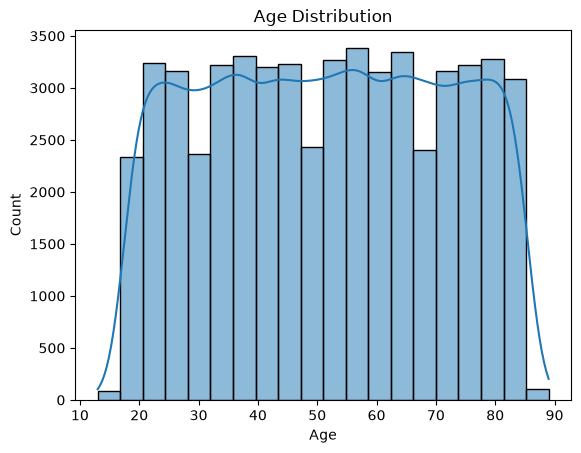

In [109]:
# Histogram for Age 
sns.histplot(df['Age'], bins = 20, kde = True) #Kernal Density Function
plt.title('Age Distribution')
plt.show()

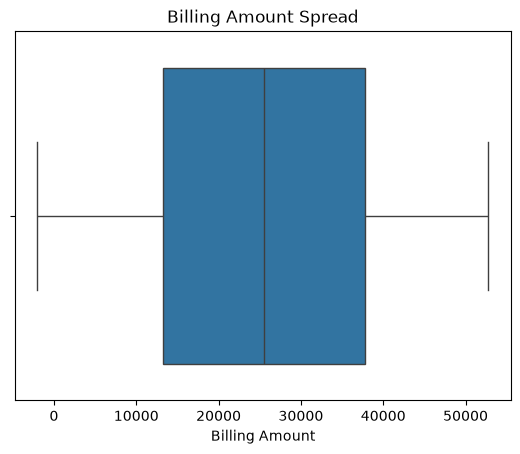

In [110]:
# Boxplot for Billing Amount
sns.boxplot(x=df['Billing Amount'])
plt.title('Billing Amount Spread')
plt.show()

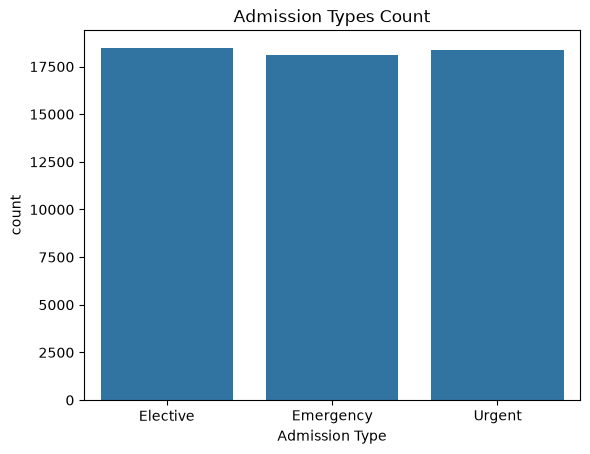

In [111]:
# Count Plot for Admission Type
sns.countplot(x='Admission Type', data=df)
plt.title('Admission Types Count')
plt.show()

### Bivariate Analysis

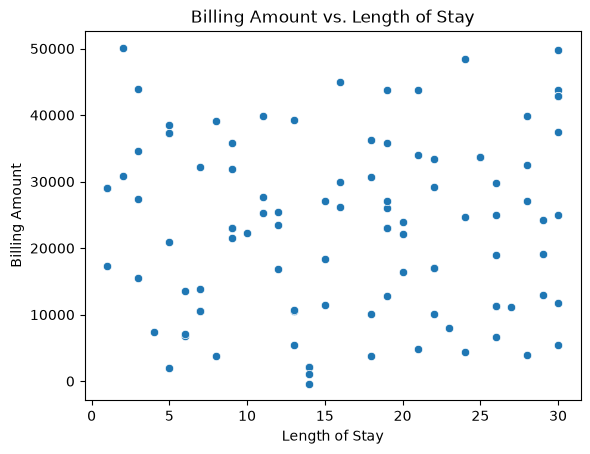

In [112]:
# Scatter Plot : Billing Amount vs. Length of Stay
sns.scatterplot(x='Length of Stay', y= 'Billing Amount', data = df.head(100))
plt.title('Billing Amount vs. Length of Stay')
plt.show()

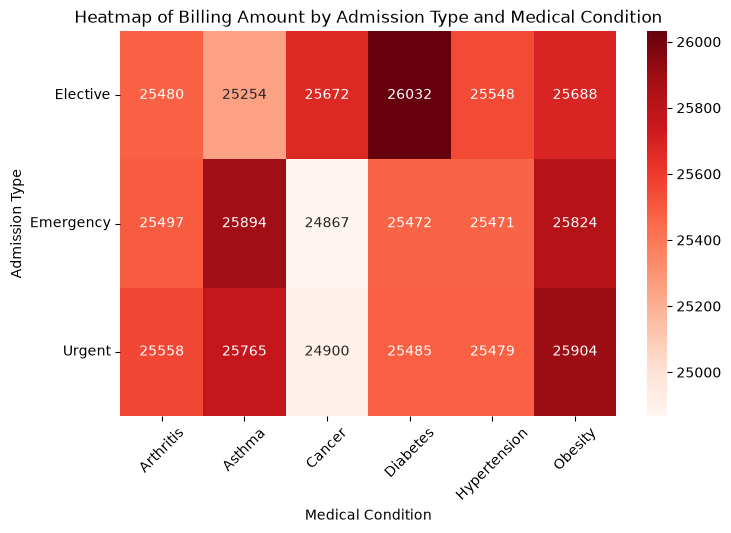

In [114]:
# Step 1: Create Pivot Table
pivot_table = df.pivot_table(
    index='Admission Type',
    columns='Medical Condition',
    values='Billing Amount',
    aggfunc='mean'
)

# Step 2: Plot Heatmap
plt.figure(figsize=(8,5))

sns.heatmap(
    pivot_table,
    annot=True,
    fmt='.0f',
    cmap='Reds'   # Light Red → Dark Red
)

plt.title('Heatmap of Billing Amount by Admission Type and Medical Condition')
plt.xlabel('Medical Condition')
plt.ylabel('Admission Type')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

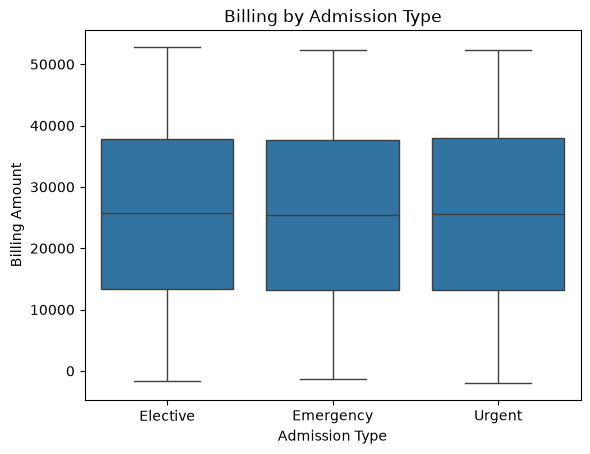

In [115]:
# Boxplot: Billing by Admission Type
sns.boxplot(x='Admission Type', y='Billing Amount', data=df)
plt.title('Billing by Admission Type')
plt.show()

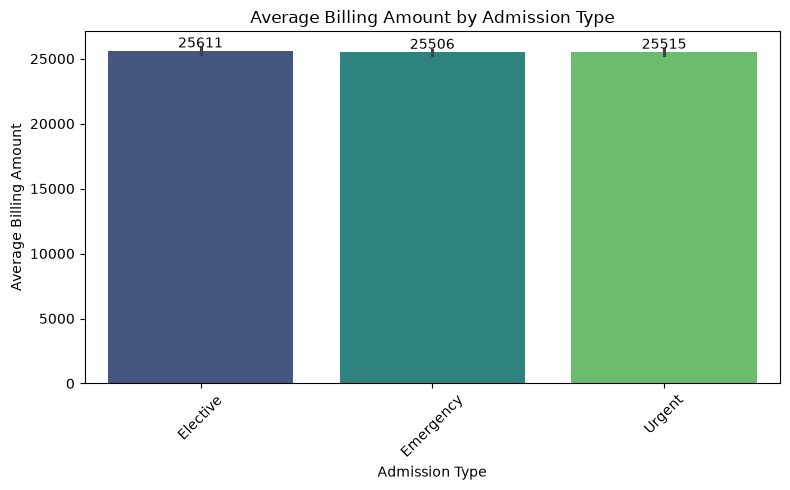

In [118]:
# Bar plots:Average Billing Amount by Admission Type
plt.figure(figsize=(8,5))

ax = sns.barplot(
    x='Admission Type',
    y='Billing Amount',
    hue='Admission Type',
    data=df,
    estimator=np.mean,
    palette='viridis',
    legend=False
)

# Data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=10)

plt.title('Average Billing Amount by Admission Type')
plt.xlabel('Admission Type')
plt.ylabel('Average Billing Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

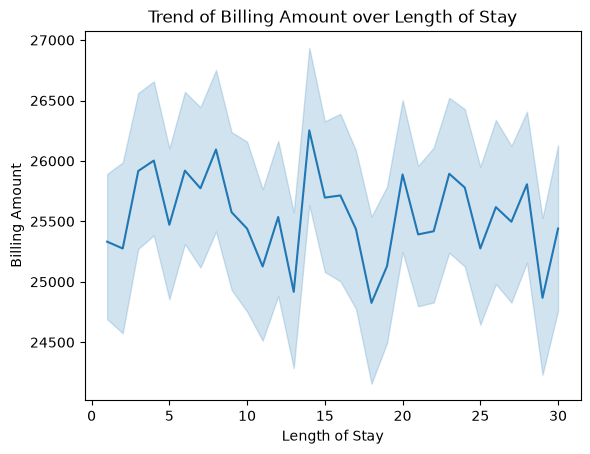

In [119]:
# Lineplot : Length of Stay vs. Billing Amount
sns.lineplot(x='Length of Stay', y ='Billing Amount', estimator = np.mean, data = df)
plt.title('Trend of Billing Amount over Length of Stay')
plt.show()

### Multivariate Analysis

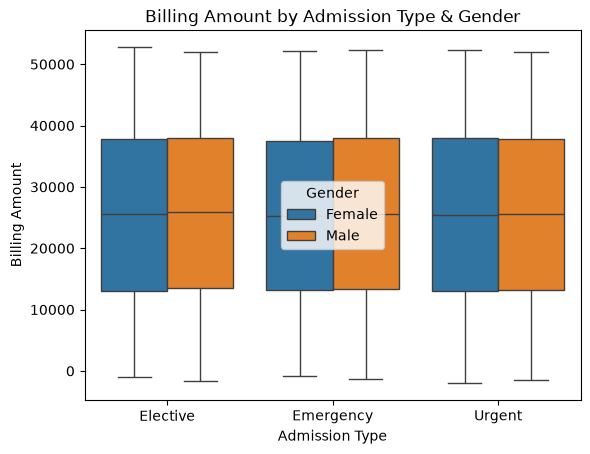

In [120]:
# Grouped Boxplot: Billing Amount across Gender & Admission Type
sns.boxplot(x='Admission Type', y= 'Billing Amount', hue = 'Gender', data = df)
plt.title('Billing Amount by Admission Type & Gender')
plt.show()

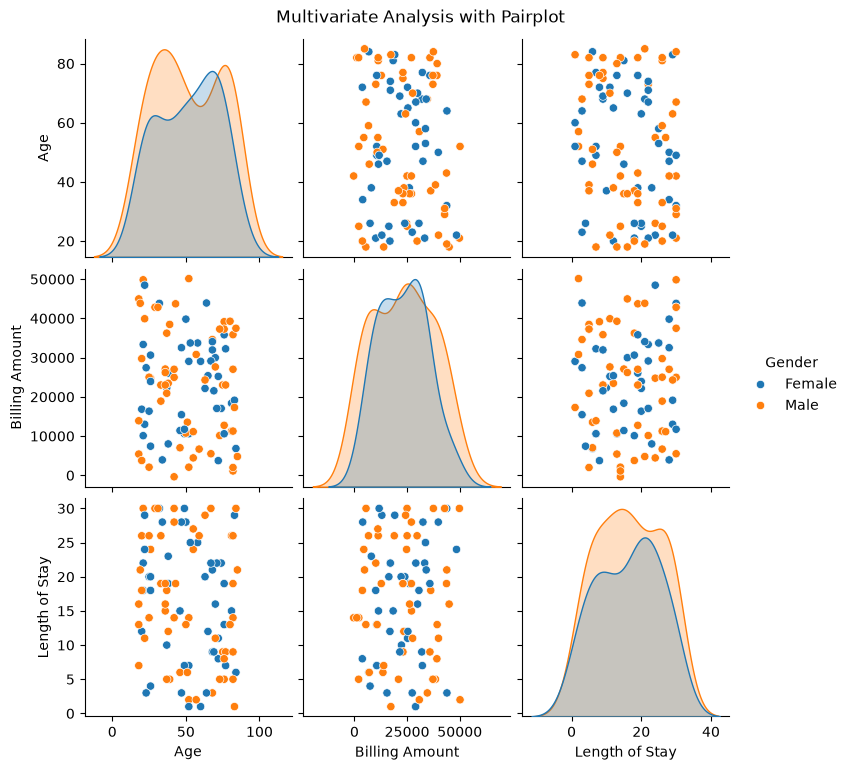

In [121]:
#Pariplot for Age, Billing Amount, Length of Stay

sns.pairplot(df.head(100), vars=['Age', 'Billing Amount', 'Length of Stay'], hue = 'Gender')
plt.suptitle('Multivariate Analysis with Pairplot', y=1.02) # y=1.02 → Adjusts the vertical position of the title.
plt.show()

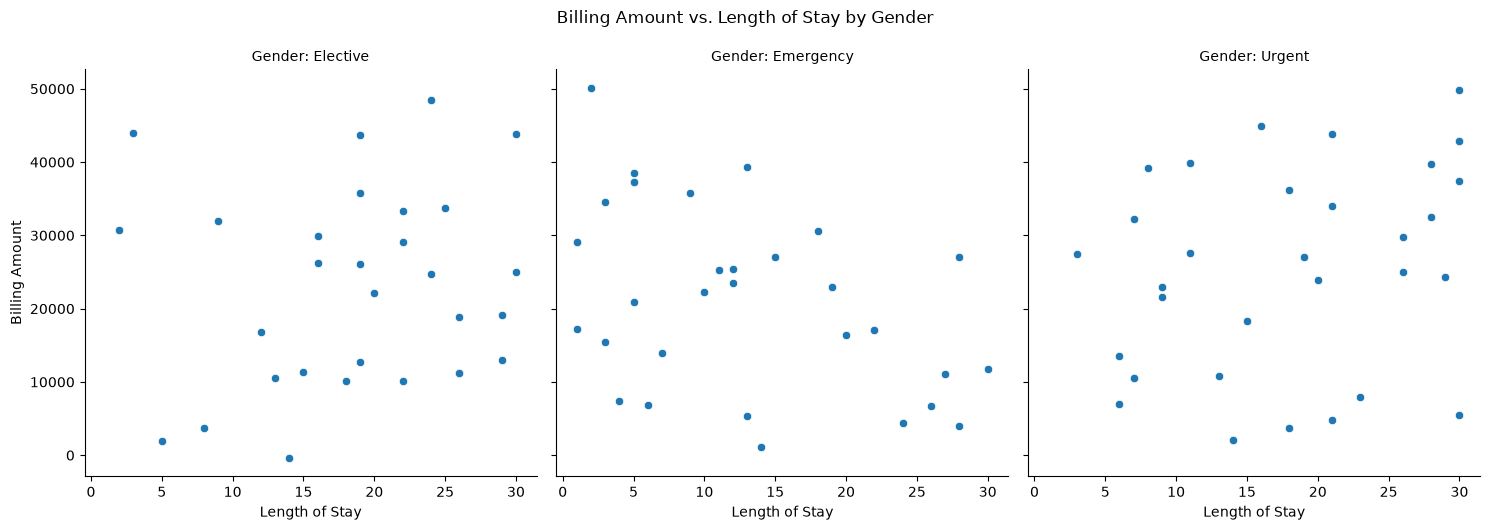

In [122]:
# Create a FacetGrid: Billing Amount vs. Length of Stay, split by Gender
g = sns.FacetGrid(df.head(100), col='Admission Type', height=5, aspect=1)
g.map_dataframe(sns.scatterplot, x='Length of Stay', y='Billing Amount')

g.set_axis_labels('Length of Stay', 'Billing Amount')
g.set_titles('Gender: {col_name}')
g.fig.suptitle('Billing Amount vs. Length of Stay by Gender', y=1.05)
plt.show()

### Distribution Plots

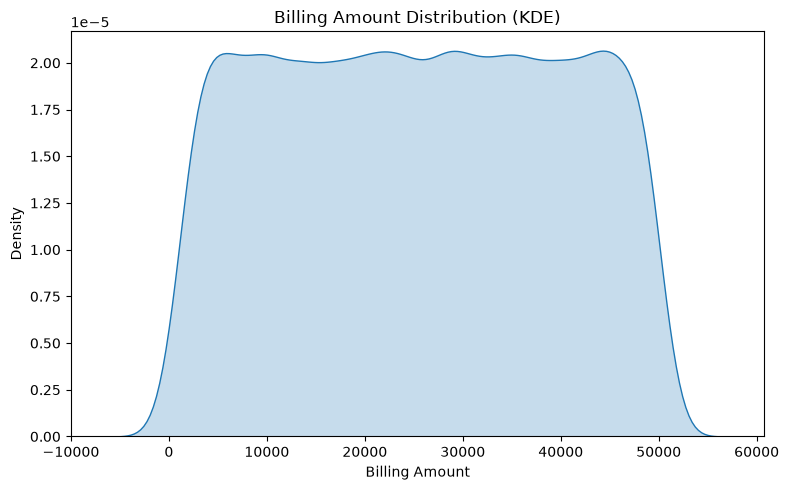

In [124]:
# KDE Plot: Billing Amount Distribution
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df,
    x='Billing Amount',
    fill=True
)

plt.title('Billing Amount Distribution (KDE)')
plt.xlabel('Billing Amount')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

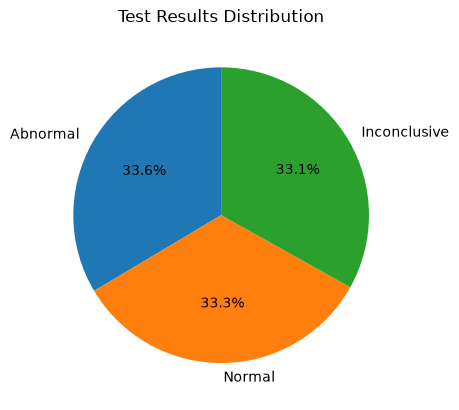

In [125]:
# Pie Chart: Gender Distribution
df['Test Results'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Test Results Distribution')
plt.ylabel('')
plt.show()

### Correlation Analysis

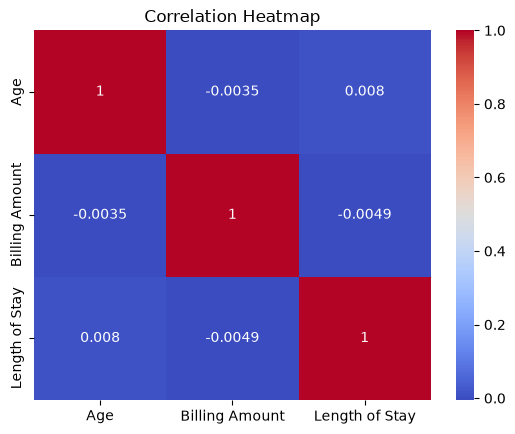

In [126]:
# Correlation Heatmap

corr = df[['Age', 'Billing Amount', 'Length of Stay']].corr() 
sns.heatmap(corr, annot = True, cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()